In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from black_scholes.closed import implied_volatility
from config.plot_settings import *

## S&P 500 volatility smile

In [2]:
spy = yf.Ticker("^SPX")

# Available expiries
print(spy.options)

expiry = '2026-06-30'
chain = spy.option_chain(expiry)
calls = chain.calls
puts  = chain.puts

S = spy.history(period='1d')['Close'].iloc[-1]
T = (pd.Timestamp(expiry) - pd.Timestamp.today()).days / 365
r = 0.05

('2026-06-01', '2026-06-02', '2026-06-03', '2026-06-04', '2026-06-05', '2026-06-08', '2026-06-09', '2026-06-10', '2026-06-11', '2026-06-12', '2026-06-15', '2026-06-16', '2026-06-17', '2026-06-18', '2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25', '2026-06-26', '2026-06-29', '2026-06-30', '2026-07-01', '2026-07-02', '2026-07-06', '2026-07-07', '2026-07-09', '2026-07-10', '2026-07-17', '2026-07-24', '2026-07-31', '2026-08-21', '2026-08-31', '2026-09-18', '2026-09-30', '2026-10-16', '2026-10-30', '2026-11-20', '2026-12-18', '2026-12-31', '2027-01-15', '2027-02-19', '2027-03-19', '2027-03-31', '2027-04-16', '2027-05-21', '2027-06-17', '2027-09-17', '2027-12-17', '2028-12-15', '2029-12-21', '2030-12-20', '2031-12-19')


In [3]:
calls = calls[(calls['bid'] > 0) & (calls['ask'] > 0)].copy()
calls['mid'] = (calls['bid'] + calls['ask']) / 2
calls['IV'] = calls.apply(
    lambda row: implied_volatility(row['mid'], S, row['strike'], r, T, option_type="call"), axis=1
)

/Users/jameswu/Documents/Imperial/Year 4/M4R/black_scholes/closed.py:110: RuntimeWarning: divide by zero encountered in scalar divide
  sigma -= price_diff / vega
/Users/jameswu/Documents/Imperial/Year 4/M4R/black_scholes/closed.py:29: RuntimeWarning: invalid value encountered in scalar divide
  d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
/Users/jameswu/Documents/Imperial/Year 4/M4R/black_scholes/closed.py:104: RuntimeWarning: invalid value encountered in scalar divide
  vega = (S * norm.pdf((np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))) * np.sqrt(T))
/Users/jameswu/Documents/Imperial/Year 4/M4R/black_scholes/closed.py:29: RuntimeWarning: overflow encountered in scalar power
  d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
/Users/jameswu/Documents/Imperial/Year 4/M4R/black_scholes/closed.py:104: RuntimeWarning: overflow encountered in scalar power
  vega = (S * norm.pdf((np.log(S / K) + (r + 0.5 * sigma ** 2) 

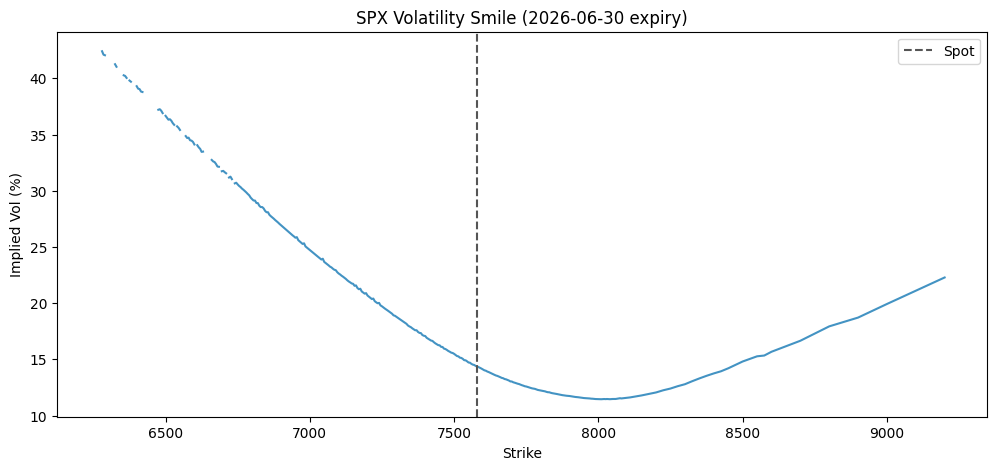

In [4]:
plt.figure(figsize=figsize2)
plt.plot(calls['strike'], calls['IV'] * 100)
plt.axvline(S, color=GRAPHITE, linestyle='--', label='Spot')
plt.xlabel('Strike'); plt.ylabel('Implied Vol (%)')
plt.title(f'SPX Volatility Smile ({expiry} expiry)')
plt.legend()
plt.savefig('../../plots/introduction/spx_vol_smile.png')
plt.show()

## Heston model

In [5]:
from heston.tree import HestonTreeFast

S0 = 100.0
K = 100.0
T = 0.5
r = 0.05
kappa = 2.0
theta = 0.04
sigma = 0.3
rho = -0.7
v0 = 0.04

n = 50
mv = 3 * n
mz = 6 * n
V0_min = v0 * 0.25
V0_max = v0 * 3
S0_min = S0 * 0.99
S0_max = S0 * 1.01


In [6]:
strikes = np.linspace(S0 * 0.6, S0 * 1.4, 100)

implied_vols = []
implied_vols_n = []

for K_ in strikes:
    option_type = "put" if K_ <= S0 else "call"

    tree = HestonTreeFast(n, mz, mv, K_, T, r, kappa, theta, sigma, rho)
    tree.build_tree(V0_min=V0_min, V0_max=V0_max, S0_min=S0_min, S0_max=S0_max,
                    option_type=option_type, exercise_type="european")
    price = tree.price(v0, S0, 0)
    implied_vols.append(implied_volatility(price, S0, K_, r, T, option_type))

    tree_n = HestonTreeFast(n, mz, mv, K_, T, r, kappa, theta, sigma, -rho)
    tree_n.build_tree(V0_min=V0_min, V0_max=V0_max, S0_min=S0_min, S0_max=S0_max,
                      option_type=option_type, exercise_type="european")
    price_n = tree_n.price(v0, S0, 0)
    implied_vols_n.append(implied_volatility(price_n, S0, K_, r, T, option_type))


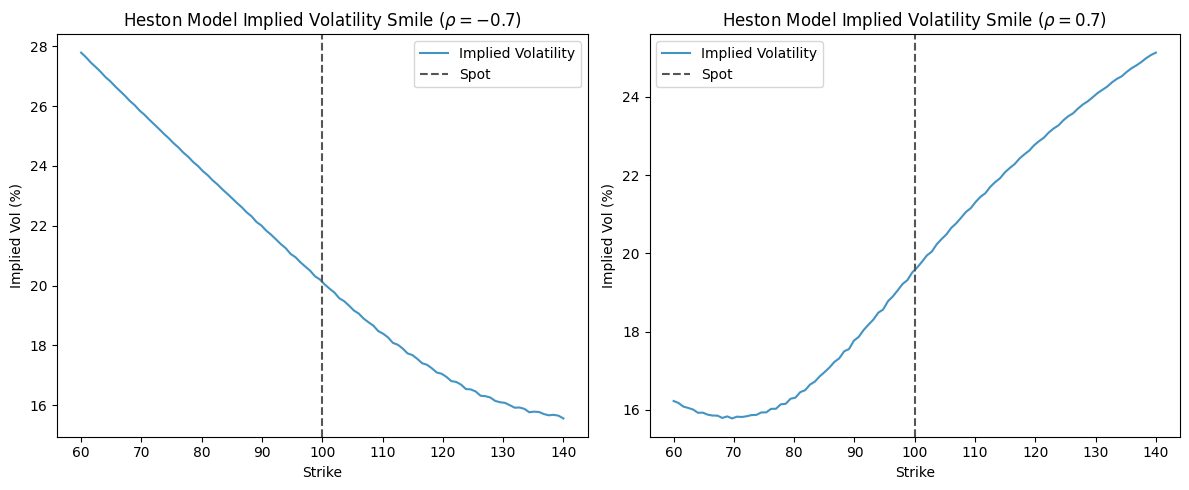

In [7]:
plt.figure(figsize=figsize2)
plt.subplot(1, 2, 1)
plt.plot(strikes, np.array(implied_vols) * 100, label='Implied Volatility')
plt.axvline(S0, color=GRAPHITE, linestyle='--', label='Spot')
plt.xlabel('Strike')
plt.ylabel('Implied Vol (%)')
plt.title(r'Heston Model Implied Volatility Smile ($\rho = -0.7$)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(strikes, np.array(implied_vols_n) * 100, label='Implied Volatility')
plt.axvline(S0, color=GRAPHITE, linestyle='--', label='Spot')
plt.xlabel('Strike')
plt.ylabel('Implied Vol (%)')
plt.title(r'Heston Model Implied Volatility Smile ($\rho = 0.7$)')
plt.legend()

plt.tight_layout()
plt.savefig('../../plots/heston/vol_smile.png')
plt.show()